In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

In [7]:
np.random.seed(42)
x_dt0 = np.random.normal(loc=[30, 40000], scale=[0, 10000], size=(60, 2))
y_dt0 = np.zeros(60)
x_dt1 = np.random.normal(loc=[50, 70000], scale=[10, 15000], size=(60, 2))
y_dt1 = np.ones(60)
x_dt = np.vstack((x_dt0, x_dt1))
y_dt = np.hstack((y_dt0, y_dt1))
df_dt = pd.DataFrame(x_dt, columns=['Age', 'Income'])
df_dt['Decision'] = y_dt
display(df_dt.head())

,Age,Income,Decision
0,30.0,38617.356988,0.0
1,30.0,55230.298564,0.0
2,30.0,37658.630431,0.0
3,30.0,47674.347292,0.0
4,30.0,45425.600436,0.0


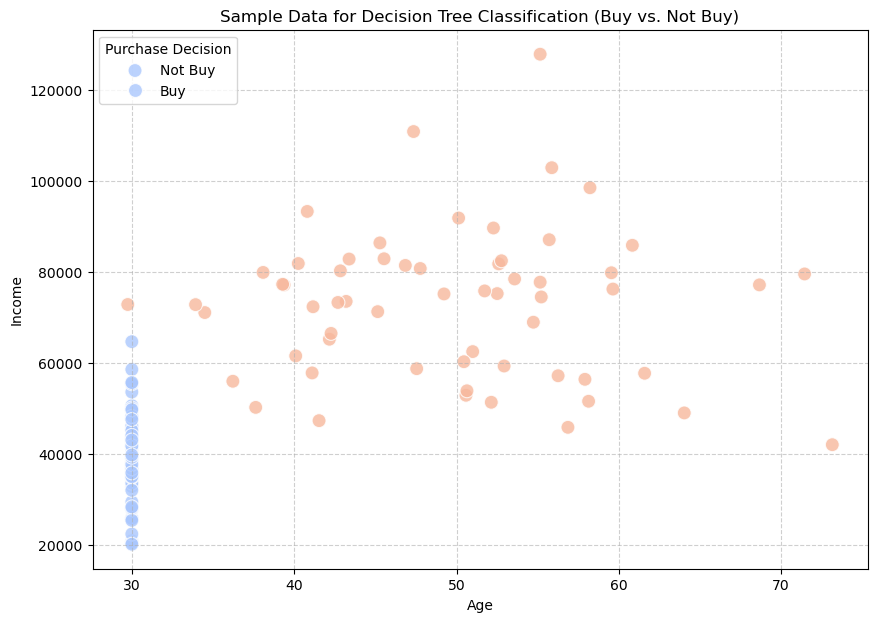

In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='Income', hue='Decision', data=df_dt, palette='coolwarm', s=100, alpha=0.8)
plt.title('Sample Data for Decision Tree Classification (Buy vs. Not Buy)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Purchase Decision', loc='upper left', labels=['Not Buy', 'Buy'])
plt.show()

In [9]:
x_dt_train, x_dt_test, y_dt_train, y_dt_test = train_test_split(x_dt, y_dt, test_size=0.3, random_state=42)

print(f"Training set shape for DT: {x_dt_train.shape}, {y_dt_train.shape}")
print(f"Testing set shape for DT: {x_dt_test.shape}, {y_dt_test.shape}")

Training set shape for DT: (84, 2), (84,)
Testing set shape for DT: (36, 2), (36,)


In [10]:
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_classifier.fit(x_dt_train, y_dt_train)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


In [11]:
y_dt_pred = dt_classifier.predict(x_dt_test)

print("First 10 actual labels for DT:", y_dt_test[:10])
print("First 10 predicted labels for DT:", y_dt_pred[:10])

First 10 actual labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]


In [12]:
dt_accuracy = accuracy_score(y_dt_test, y_dt_pred)
dt_report = classification_report(y_dt_test, y_dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print("Decision Tree Classification Report:\n", dt_report)

Decision Tree Accuracy: 0.97
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.97        19
         1.0       0.94      1.00      0.97        17

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

